# Image Preprocessing & Augmentation — Hands-on with Keras

**Companion notebook to the hand-written class notes on Image Preprocessing and Augmentation.**

Sections in this notebook:
1. Image Preprocessing (resizing, rescaling, normalization, loading a dataset)
2. Image Augmentation (random flips, rotations, zooms, crops, brightness/contrast)
3. Combining Preprocessing & Augmentation into a real pipeline

Like the previous notebook, each section is written to be **self-contained** (re-imports what it needs, redefines any helper it uses) so it can be split into a separate file per lecture.

### Quick Keras recap
- `keras.layers.*` — building blocks of a model.
- `keras.Sequential([...])` — stacks layers linearly; used throughout this notebook.
- Many preprocessing/augmentation layers behave **differently in training vs. inference**: call them as `layer(x, training=True)` to force the "training" behaviour (e.g. actually apply a random flip) even outside of `model.fit`. This is exactly how we'll demonstrate them below.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("TensorFlow version:", tf.__version__)
print("Keras version     :", keras.__version__)

keras.utils.set_random_seed(42)   # seeds python/numpy/backend RNGs together
plt.rcParams["figure.figsize"] = (10, 4)


TensorFlow version: 2.20.0
Keras version     : 3.13.2


---
# 1. Image Preprocessing

### Why preprocess?
Raw images rarely arrive in the exact numeric format a network expects: they can be any size, any pixel-value range (usually `0-255`), and sometimes the wrong number of channels. **Preprocessing** turns raw images into a consistent tensor: fixed height/width, a sensible value range, and (optionally) zero mean / unit variance.

### Keras layers used here

```python
keras.layers.Resizing(height, width, interpolation="bilinear")
# Resizes every image to a fixed (height, width), regardless of its original size.

keras.layers.Rescaling(scale, offset=0.0)
# output = input * scale + offset
# e.g. Rescaling(1./255) maps pixel values from [0, 255] to [0, 1]

keras.layers.CenterCrop(height, width)
# Crops out the centre (height, width) region of an image.

keras.layers.Normalization(axis=-1)
# Standardises data to zero mean / unit variance PER CHANNEL.
# You must call `layer.adapt(data)` once first, so it can learn the
# mean & variance from your data (this is NOT random/trainable -- it's
# computed once, then applied deterministically, similar to sklearn's
# StandardScaler).
```

### Loading a real dataset (for reference)
For an actual folder of images organised as `data/<class_name>/*.jpg`, Keras can build a ready-to-use `tf.data.Dataset` in one call:

```python
train_ds = keras.utils.image_dataset_from_directory(
    "data",
    image_size=(180, 180),   # resizes every image while loading
    batch_size=32,
    label_mode="int",        # or "categorical" / "binary"
    validation_split=0.2,
    subset="training",
    seed=123,
)
```

We don't have an actual folder of images in this notebook, so below we build one small **synthetic** RGB image with `numpy` and preprocess *that* instead — the operations are identical to what you'd do on real photos.

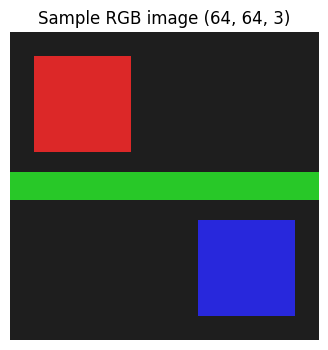

In [2]:
def create_sample_rgb_image(size=64):
    """A small synthetic RGB image with clearly asymmetric colour blocks,
    so that flips/rotations/zooms/crops are all easy to see visually.
    Pixel values are in the usual [0, 255] range, like a real photo."""
    img = np.full((size, size, 3), 30, dtype="float32")               # dark background
    img[5:25, 5:25] = [220, 40, 40]                                    # red square, top-left
    img[size - 25:size - 5, size - 25:size - 5] = [40, 40, 220]        # blue square, bottom-right
    img[size // 2 - 3:size // 2 + 3, :] = [40, 200, 40]                # green horizontal stripe
    return img

sample_image_rgb = create_sample_rgb_image()

plt.imshow(sample_image_rgb.astype("uint8"))
plt.title(f"Sample RGB image {sample_image_rgb.shape}")
plt.axis("off")
plt.show()


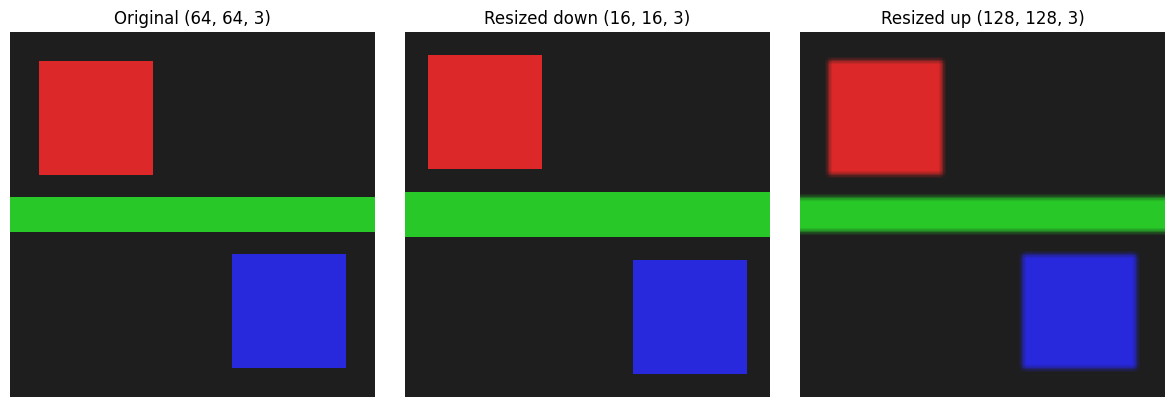

In [3]:
img_batch = sample_image_rgb.reshape(1, 64, 64, 3)

resize_down = layers.Resizing(height=16, width=16)
resize_up   = layers.Resizing(height=128, width=128)

small = resize_down(img_batch).numpy()[0]
large = resize_up(img_batch).numpy()[0]

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(sample_image_rgb.astype("uint8")); axes[0].set_title(f"Original {sample_image_rgb.shape}"); axes[0].axis("off")
axes[1].imshow(small.astype("uint8"));            axes[1].set_title(f"Resized down {small.shape}");        axes[1].axis("off")
axes[2].imshow(large.astype("uint8"));            axes[2].set_title(f"Resized up {large.shape}");          axes[2].axis("off")
plt.tight_layout()
plt.show()


In [4]:
rescale_layer = layers.Rescaling(scale=1.0 / 255)
rescaled = rescale_layer(img_batch).numpy()[0]

print("Before Rescaling -> min:", sample_image_rgb.min(), " max:", sample_image_rgb.max())
print("After  Rescaling -> min:", rescaled.min(),          " max:", rescaled.max())


Before Rescaling -> min: 30.0  max: 220.0
After  Rescaling -> min: 0.11764707  max: 0.86274517


In [5]:
norm_layer = layers.Normalization()
norm_layer.adapt(img_batch)   # learns per-channel mean & variance from the data given

normalized = norm_layer(img_batch).numpy()[0]

print("Before normalization -> mean per channel:", img_batch[0].mean(axis=(0, 1)))
print("After  normalization -> mean per channel:", normalized.mean(axis=(0, 1)).round(4))
print("After  normalization -> std  per channel:", normalized.std(axis=(0, 1)).round(4))


Before normalization -> mean per channel: [50.46875  47.890625 50.46875 ]
After  normalization -> mean per channel: [ 0.  0. -0.]
After  normalization -> std  per channel: [1. 1. 1.]


**Note:** `Resizing`, `Rescaling` and `Normalization` are *deterministic* — they do the exact same thing whether the model is training or being used for inference. That means it's safe (and recommended) to bake them **directly into the model** as its first layers: the same preprocessing then automatically travels with the model wherever it's saved/deployed, so you never forget to "resize + rescale" before calling `predict` later. Augmentation layers, covered next, are different — they're randomised, and only fire during training.

---
# 2. Image Augmentation

### Why augment?
A CNN trained on too few images tends to **overfit** — it memorises the exact pixels of the training set instead of learning the underlying pattern. **Data augmentation** creates many random, realistic variations of each training image on the fly (flipped, rotated, zoomed, brighter/darker, cropped, ...), so the network effectively sees a much larger and more varied dataset, and learns to be invariant to these changes.

### Keras layers used here

```python
keras.layers.RandomFlip(mode="horizontal")
# mode: "horizontal", "vertical", or "horizontal_and_vertical"

keras.layers.RandomRotation(factor=0.15)
# factor is a fraction of a full rotation (2*pi radians).
# factor=0.15 -> randomly rotate within roughly +/-54 degrees.

keras.layers.RandomZoom(height_factor=(-0.2, 0.2))
# Negative = zoom IN, positive = zoom OUT. A tuple picks randomly within that range.

keras.layers.RandomTranslation(height_factor=0.1, width_factor=0.1)
# Randomly shifts the image up/down/left/right by up to 10% of its size.

keras.layers.RandomContrast(factor=0.3)
# Randomly scales contrast; factor=0.3 -> contrast multiplier in roughly [0.7, 1.3].

keras.layers.RandomBrightness(factor=0.2, value_range=(0, 255))
# Randomly brightens/darkens. value_range MUST match your actual pixel range
# (0-255 here; use (0, 1) if you've already applied Rescaling(1./255)).

keras.layers.RandomCrop(height, width)
# TRAINING: crops a random (height, width) patch out of the image.
# INFERENCE: crops the SAME patch every time -- a deterministic centre crop.
```

### The `training=` argument matters a lot here
Every layer above only behaves *randomly* when called with `training=True` (which is what happens automatically inside `model.fit(...)`). Called with `training=False` (or during plain inference/evaluation), most of them simply **pass the image through unchanged** — augmentation is a training-time-only trick, never applied to validation/test/real-world images. `RandomCrop` is the one exception worth remembering: at inference it still crops, just deterministically (centre crop) rather than randomly, so the output size still matches what the rest of the model expects.

In [6]:
# (safe to re-run if you're using this section on its own)
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

def create_sample_rgb_image(size=64):
    img = np.full((size, size, 3), 30, dtype="float32")
    img[5:25, 5:25] = [220, 40, 40]
    img[size - 25:size - 5, size - 25:size - 5] = [40, 40, 220]
    img[size // 2 - 3:size // 2 + 3, :] = [40, 200, 40]
    return img

sample_image_rgb = create_sample_rgb_image()
img_batch = sample_image_rgb.reshape(1, 64, 64, 3)


In [7]:
augmentation = keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(factor=0.15),
    layers.RandomZoom(height_factor=(-0.2, 0.2)),
    layers.RandomTranslation(height_factor=0.1, width_factor=0.1),
    layers.RandomContrast(factor=0.3),
    layers.RandomBrightness(factor=0.2, value_range=(0, 255)),
])


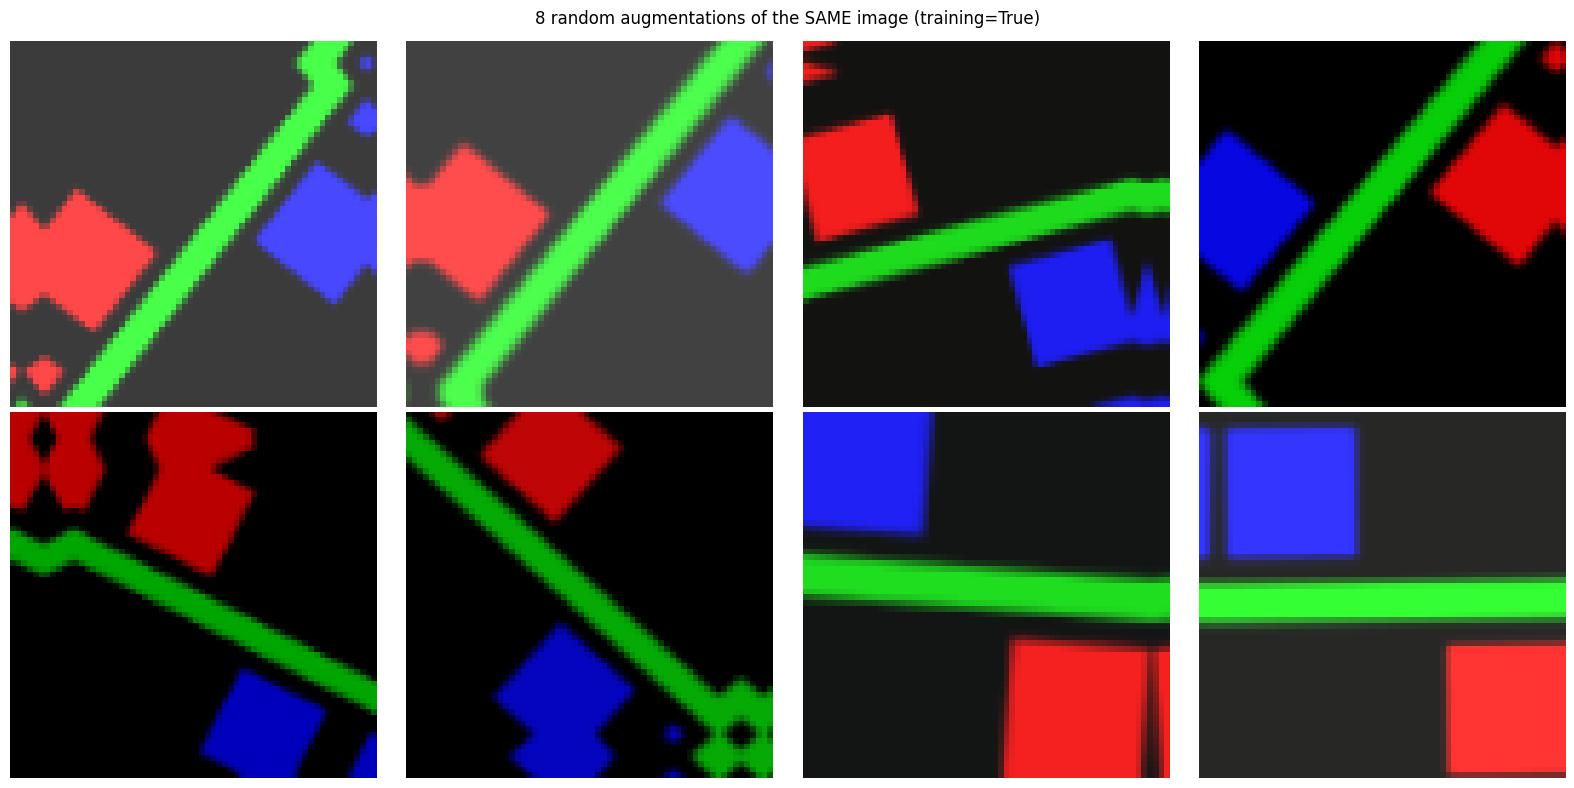

In [8]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.ravel()

for ax in axes:
    augmented = augmentation(img_batch, training=True).numpy()[0]
    augmented = np.clip(augmented, 0, 255).astype("uint8")
    ax.imshow(augmented)
    ax.axis("off")

plt.suptitle("8 random augmentations of the SAME image (training=True)")
plt.tight_layout()
plt.show()


In [9]:
flip_layer = layers.RandomFlip("horizontal")

out_infer = flip_layer(img_batch, training=False).numpy()
out_train = flip_layer(img_batch, training=True).numpy()

print("training=False -> identical to original:", np.allclose(out_infer, img_batch))
print("training=True  -> identical to original:", np.allclose(out_train, img_batch))
# (training=True has a 50% chance of NOT flipping too -- re-run this cell a
#  few times and you'll occasionally see "True" there as well, by chance.)


training=False -> identical to original: True
training=True  -> identical to original: True


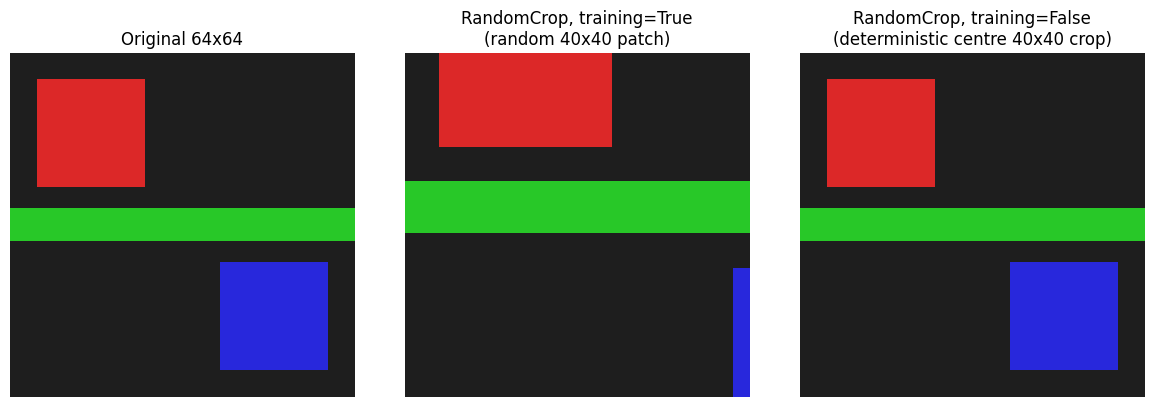

In [10]:
crop_layer = layers.RandomCrop(height=40, width=40)

cropped_train = crop_layer(img_batch, training=True).numpy()[0]
cropped_infer = crop_layer(img_batch, training=False).numpy()[0]

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(sample_image_rgb.astype("uint8"))
axes[0].set_title("Original 64x64")
axes[0].axis("off")
axes[1].imshow(cropped_train.astype("uint8"))
axes[1].set_title("RandomCrop, training=True\n(random 40x40 patch)")
axes[1].axis("off")
axes[2].imshow(cropped_infer.astype("uint8"))
axes[2].set_title("RandomCrop, training=False\n(deterministic centre 40x40 crop)")
axes[2].axis("off")
plt.tight_layout()
plt.show()


### A note on the older `ImageDataGenerator` API
Older tutorials and codebases (pre-Keras-3) often augment images with `keras.preprocessing.image.ImageDataGenerator` instead of the layers above:

```python
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True,
    rescale=1.0 / 255,
)

train_generator = datagen.flow_from_directory(
    "data", target_size=(150, 150), batch_size=32, class_mode="binary"
)
```

This still works in many environments, but it is **legacy** — it's slower (runs on the CPU, outside the `tf.data`/graph pipeline), and can't be embedded inside the model itself the way the layers in this notebook can. It's worth being able to *recognise* this syntax, but for new code prefer the `RandomFlip` / `RandomRotation` / ... layers above.

---
# 3. Combining Preprocessing & Augmentation into a Pipeline

There are two equally valid places to put these layers:

**(a) Inside the model itself** — as its first few layers. Simple, and the preprocessing/augmentation logic travels with the model wherever it's saved. Deterministic layers (`Resizing`, `Rescaling`, `Normalization`) behave the same in training and inference; random layers (`RandomFlip`, `RandomRotation`, ...) automatically switch themselves off during evaluation/inference — you don't have to do anything extra.

**(b) Inside a `tf.data` pipeline**, via `.map(...)` on the dataset, *before* the data ever reaches the model. Common for larger datasets, since it lets image loading/augmentation run in parallel on the CPU while the GPU is busy training on the previous batch.

In [11]:
# (a) Preprocessing + augmentation as the first layers of the model
model = keras.Sequential([
    keras.Input(shape=(64, 64, 3)),
    layers.Resizing(32, 32),
    layers.Rescaling(1.0 / 255),
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.Conv2D(16, 3, activation="relu"),
    layers.MaxPooling2D(2),
    layers.Conv2D(32, 3, activation="relu"),
    layers.MaxPooling2D(2),
    layers.Flatten(),
    layers.Dense(10, activation="softmax"),
])

model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ resizing_2 (Resizing)                │ (None, 32, 32, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ rescaling_1 (Rescaling)              │ (None, 32, 32, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ random_flip_2 (RandomFlip)           │ (None, 32, 32, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ random_rotation_1 (RandomRotation)   │ (None, 32, 32, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 30, 30, 16)          │             448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 15, 15, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 13, 13, 32)          │           4,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 6, 6, 32)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 1152)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 10)                  │          11,530 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 16,618 (64.91 KB)

 Trainable params: 16,618 (64.91 KB)

 Non-trainable params: 0 (0.00 B)

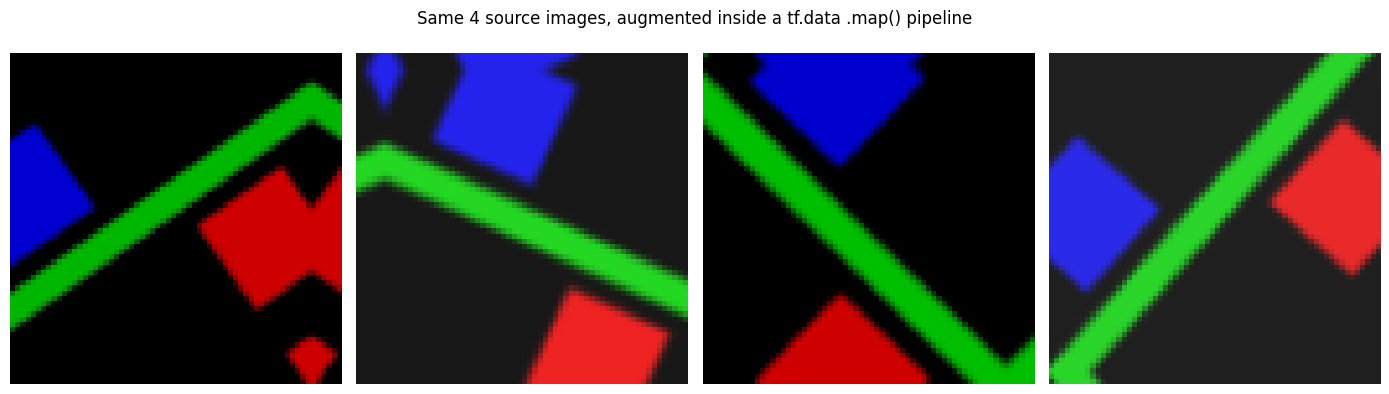

In [12]:
# (b) Preprocessing + augmentation inside a tf.data pipeline
# Simulate a tiny "dataset" of 4 copies of our sample image
raw_images = np.stack([sample_image_rgb] * 4).astype("float32")

dataset = tf.data.Dataset.from_tensor_slices(raw_images)
dataset = dataset.batch(4)
dataset = dataset.map(lambda x: augmentation(x, training=True))

augmented_batch = next(iter(dataset)).numpy()

fig, axes = plt.subplots(1, 4, figsize=(14, 4))
for ax, img in zip(axes, augmented_batch):
    ax.imshow(np.clip(img, 0, 255).astype("uint8"))
    ax.axis("off")
plt.suptitle("Same 4 source images, augmented inside a tf.data .map() pipeline")
plt.tight_layout()
plt.show()


---
## Quick recap

| Concept | Keras class |
|---|---|
| Resize to a fixed size | `layers.Resizing` |
| Scale pixel values | `layers.Rescaling` |
| Crop to a fixed centre region | `layers.CenterCrop` |
| Standardise to mean 0 / std 1 | `layers.Normalization` (+ `.adapt(data)`) |
| Load a labelled folder of images | `keras.utils.image_dataset_from_directory` |
| Random flip | `layers.RandomFlip` |
| Random rotation | `layers.RandomRotation` |
| Random zoom in/out | `layers.RandomZoom` |
| Random shift | `layers.RandomTranslation` |
| Random contrast / brightness | `layers.RandomContrast` / `layers.RandomBrightness` |
| Random (train) / centre (inference) crop | `layers.RandomCrop` |
| Legacy augmentation API | `keras.preprocessing.image.ImageDataGenerator` |

**Rule of thumb:** deterministic preprocessing layers are safe to put anywhere and always behave the same; random augmentation layers should only ever be *active* during training — which Keras handles for you automatically via the `training` flag, as long as they sit inside a proper `keras.Model`/`Sequential` or are explicitly called with `training=True`/`False`.

This notebook is meant to be read alongside the hand-written notes. Split it at the `# 1.` / `# 2.` / `# 3.` headings into separate files for separate class sessions, if needed.

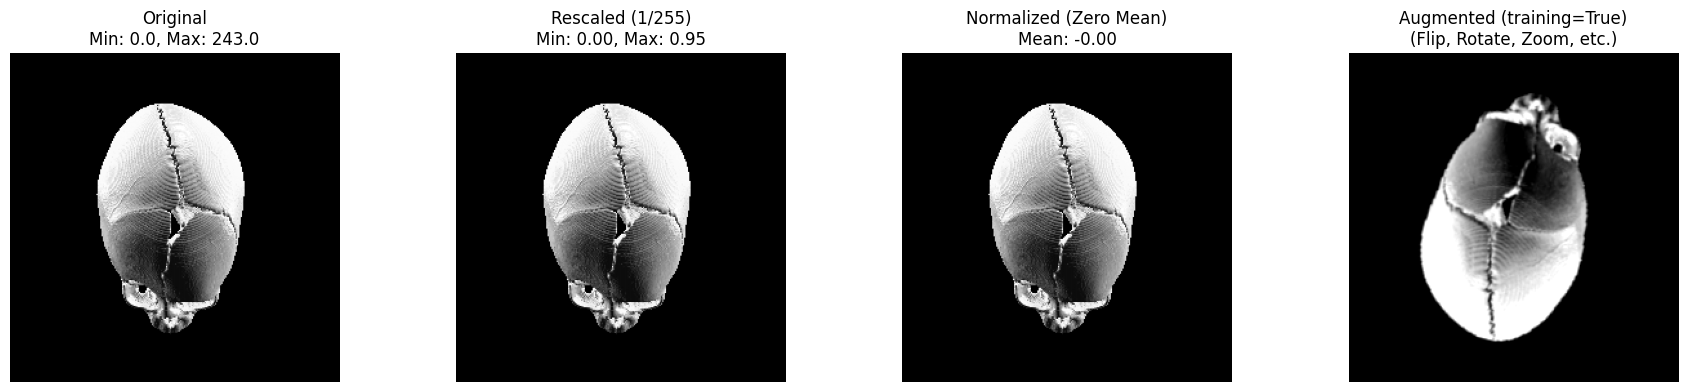

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.utils import load_img, img_to_array

# --- 1. LOAD THE LOCAL IMAGE ---
# Ensure the image file is in the same directory as your notebook
image_path = "Fig0122(c)(skull).tif"

# Load the image as grayscale and resize it to 256x256
img_gray = img_to_array(load_img(image_path, color_mode="grayscale", target_size=(256, 256)))

# Keras expects a batch dimension: (Batch_Size, Height, Width, Channels)
batch_gray = np.expand_dims(img_gray, axis=0)

# --- 2. DEFINE PREPROCESSING & AUGMENTATION LAYERS ---
rescale_layer = layers.Rescaling(scale=1.0 / 255)

# Normalization needs to "adapt" to the channel statistics of the image
norm_layer = layers.Normalization()
norm_layer.adapt(batch_gray)

# The augmentation pipeline
augmentation = keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(factor=0.15),
    layers.RandomZoom(height_factor=(-0.2, 0.2)),
    layers.RandomTranslation(height_factor=0.1, width_factor=0.1),
    layers.RandomContrast(factor=0.3),
    layers.RandomBrightness(factor=0.2, value_range=(0, 255)),
])

# --- 3. APPLY OPERATIONS ---
rescaled_gray = rescale_layer(batch_gray).numpy()[0]
normalized_gray = norm_layer(batch_gray).numpy()[0]
augmented_gray = augmentation(batch_gray, training=True).numpy()[0]

# --- 4. PLOTTING FUNCTION ---
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

# 1. Original (Slicing [:, :, 0] removes the channel dimension for matplotlib)
axes[0].imshow(img_gray[:, :, 0], cmap="gray")
axes[0].set_title(f"Original\nMin: {img_gray.min():.1f}, Max: {img_gray.max():.1f}")
axes[0].axis("off")

# 2. Rescaled
axes[1].imshow(rescaled_gray[:, :, 0], cmap="gray")
axes[1].set_title(f"Rescaled (1/255)\nMin: {rescaled_gray.min():.2f}, Max: {rescaled_gray.max():.2f}")
axes[1].axis("off")

# 3. Normalized
# Normalization creates negative values. We map them back to 0-1 for visualization purposes.
disp_norm = ((normalized_gray - normalized_gray.min()) / (normalized_gray.max() - normalized_gray.min()))
axes[2].imshow(disp_norm[:, :, 0], cmap="gray")
axes[2].set_title(f"Normalized (Zero Mean)\nMean: {normalized_gray.mean():.2f}")
axes[2].axis("off")

# 4. Augmented 
# Ensure augmented pixels are clipped to standard image ranges for display
disp_aug = np.clip(augmented_gray, 0, 255).astype("uint8")
axes[3].imshow(disp_aug[:, :, 0], cmap="gray")
axes[3].set_title("Augmented (training=True)\n(Flip, Rotate, Zoom, etc.)")
axes[3].axis("off")

plt.tight_layout()
plt.show()